In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ecommerce_sales.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

daily_df = df.groupby('order_date')['total_amount'].sum().reset_index()
daily_df = daily_df.set_index('order_date').asfreq('D', fill_value=0).reset_index()

C:\Users\Aditya Kumar\AppData\Local\Temp\ipykernel_4740\1691206029.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'])


In [3]:
daily_df['day_of_week'] = daily_df['order_date'].dt.dayofweek
daily_df['day_of_month'] = daily_df['order_date'].dt.day
daily_df['month'] = daily_df['order_date'].dt.month
daily_df['year'] = daily_df['order_date'].dt.year
daily_df['is_weekend'] = daily_df['day_of_week'].isin([5, 6]).astype(int)

In [4]:
for lag in [1, 7, 14, 30]:
    daily_df[f'lag_{lag}'] = daily_df['total_amount'].shift(lag)

daily_df['rolling_7_mean'] = daily_df['total_amount'].shift(1).rolling(window=7).mean()
daily_df['rolling_7_std'] = daily_df['total_amount'].shift(1).rolling(window=7).std()
daily_df['rolling_30_mean'] = daily_df['total_amount'].shift(1).rolling(window=30).mean()

model_df = daily_df.dropna().reset_index(drop=True)

In [5]:
test_days = 60
split_date = model_df['order_date'].max() - pd.Timedelta(days=test_days)

train = model_df[model_df['order_date'] < split_date]
test = model_df[model_df['order_date'] >= split_date]

features = [
    'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std', 'rolling_30_mean'
]
target = 'total_amount'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Training set: {len(X_train)} days")
print(f"Testing set: {len(X_test)} days")

Training set: 973 days
Testing set: 61 days


In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n Model Performance")
print(f"MAE  (Mean Absolute Error) : ${mae:,.2f}")
print(f"RMSE (Root Mean Sq Error)  : ${rmse:,.2f}")
print(f"R² Score                   : {r2:.4f}")


 Model Performance
MAE  (Mean Absolute Error) : $1,095.04
RMSE (Root Mean Sq Error)  : $1,782.55
R² Score                   : 0.6837


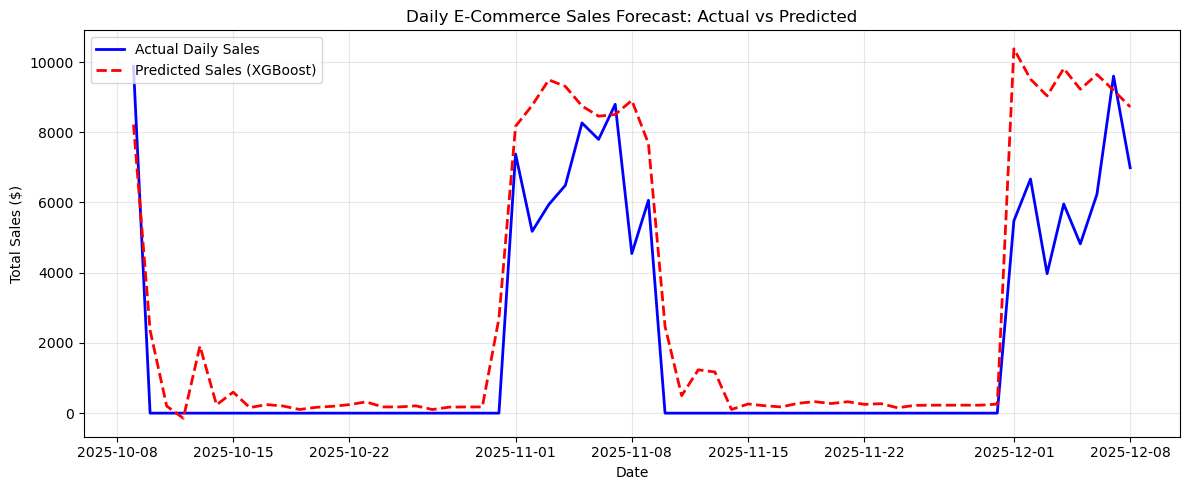

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(test['order_date'], y_test, label='Actual Daily Sales', color='blue', linewidth=2)
plt.plot(test['order_date'], y_pred, label='Predicted Sales (XGBoost)', color='red', linestyle='--', linewidth=2)
plt.title('Daily E-Commerce Sales Forecast: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()